# Binance Demo Spot - World Model Data Collection

Notebook này thu thập dữ liệu cho world-model theo Spot Demo Mode của Binance.

Mục tiêu:
- Chọn 30 cặp USDT thanh khoản cao nhất
- Chia thành 3 batch, mỗi batch 10 cặp
- Chạy một lần notebook để đi qua toàn bộ 3 batch
- Append vào `asset_klines.csv` và deduplicate theo `symbol + interval + open_time`

File đầu ra:
- `asset_klines.csv`
- `benchmark_klines.csv`
- `portfolio_positions.csv`
- `top_20_usdt_symbols.csv`

In [22]:
# Cell 1 - Imports

import os
import time
import hmac
import hashlib
from urllib.parse import urlencode
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import requests
import pandas as pd

In [3]:
# Cell 2 - Configuration

API_KEY = os.getenv("BINANCE_DEMO_API_KEY")
API_SECRET = os.getenv("BINANCE_DEMO_API_SECRET")

BASE_URL = "https://demo-api.binance.com/api"

TARGET_QUOTE_ASSET = "USDT"
TOP_N_SYMBOLS = 20
BATCH_SIZE = 10
BATCH_INDICES = [0, 1]

INTERVAL = "15m"
START_TIME = "2026-02-01 00:00:00"
END_TIME = "2026-04-07 23:59:59"

BENCHMARK_SYMBOLS = ["BTCUSDT", "ETHUSDT"]

OMIT_ZERO_BALANCES = True

OUTPUT_DIR = "./data_raw"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Output directory:", OUTPUT_DIR)

Output directory: ./data_raw


In [4]:
# Cell 3 - Utility functions

def to_millis(dt_str: str) -> int:
    return int(pd.Timestamp(dt_str, tz="UTC").timestamp() * 1000)

def from_millis(ms: int) -> pd.Timestamp:
    return pd.to_datetime(ms, unit="ms", utc=True)

def sign_params(params: Dict[str, object], api_secret: str) -> str:
    query_string = urlencode(params, doseq=True)
    return hmac.new(
        api_secret.encode("utf-8"),
        query_string.encode("utf-8"),
        hashlib.sha256
    ).hexdigest()

def save_append_dedup(
    new_df: pd.DataFrame,
    csv_path: str,
    dedup_subset: List[str],
    sort_cols: List[str],
    parse_dates: Optional[List[str]] = None
) -> pd.DataFrame:
    if os.path.exists(csv_path):
        existing_df = pd.read_csv(csv_path, parse_dates=parse_dates)
        combined_df = pd.concat([existing_df, new_df], ignore_index=True)
    else:
        combined_df = new_df.copy()

    combined_df = (
        combined_df
        .drop_duplicates(subset=dedup_subset)
        .sort_values(sort_cols)
        .reset_index(drop=True)
    )
    combined_df.to_csv(csv_path, index=False)
    return combined_df

def make_request(method, path, params=None, headers=None, signed=False, max_retries=3, timeout=60):
    url = f"{BASE_URL}{path}"
    if params is None: params = {}
    params = dict(params)
    if signed:
        params["timestamp"] = int(time.time() * 1000)
        params["recvWindow"] = 5000
        params["signature"] = sign_params(params, API_SECRET)
        if headers is None: headers = {}
        headers["X-MBX-APIKEY"] = API_KEY
    last_err = None
    for attempt in range(max_retries):
        try:
            r = requests.request(method=method, url=url, params=params, headers=headers, timeout=timeout)
            r.raise_for_status()
            return r.json()
        except (requests.exceptions.ReadTimeout, requests.exceptions.ConnectionError) as e:
            last_err = e
            wait_time = (attempt + 1) * 2
            print(f"  [Attempt {attempt+1}/{max_retries}] Lỗi: {e}. Thử lại sau {wait_time}s...")
            time.sleep(wait_time)
        except requests.exceptions.HTTPError as e:
            if e.response.status_code == 429: # Rate Limit
                retry_after = int(e.response.headers.get("Retry-After", 60))
                print(f"  [Rate Limit] Đợi {retry_after}s...")
                time.sleep(retry_after)
                continue
            raise e
    raise last_err
    
def public_get(path, params=None):
    return make_request("GET", path, params=params, signed=False)
    
def signed_get(path, params=None):
    return make_request("GET", path, params=params, signed=True)


## Build supervised panel dataset for asset-level forecasting

Phần này chuyển `asset_klines.csv` và `benchmark_klines.csv` thành một **panel dataset ở cấp (symbol, timestamp)** để huấn luyện LightGBM.

Thiết kế:
- Mỗi dòng là một asset tại một timestamp 15m
- Feature gồm:
  - asset-specific lag/momentum/volatility/range/volume features
  - benchmark / market-state features
  - relative-strength features
  - calendar features
- Target là forward return ở nhiều horizon, ưu tiên `target_ret_96` cho 24h
- Không dùng `portfolio_positions.csv`; holdings chỉ cần ở bước inference


In [5]:

# Cell 13 - Dataset configuration

DATASET_OUTPUT_DIR = "./data_model"
os.makedirs(DATASET_OUTPUT_DIR, exist_ok=True)

PANEL_DATASET_CSV_PATH = os.path.join(DATASET_OUTPUT_DIR, "model_dataset_15m_asset_panel.csv")
PANEL_DATASET_PARQUET_PATH = os.path.join(DATASET_OUTPUT_DIR, "model_dataset_15m_asset_panel.parquet")

ASSET_LAGS = [1, 2, 4, 8, 16, 32, 64]
ASSET_MOM_WINDOWS = [4, 8, 16, 32, 64]
ASSET_VOL_WINDOWS = [4, 8, 16, 32, 64]
ASSET_VOLZ_WINDOWS = [16, 32, 64]

BENCH_LAGS = [1, 2, 4, 8, 16, 32]
BENCH_MOM_WINDOWS = [4, 8, 16, 32]
BENCH_VOL_WINDOWS = [4, 8, 16, 32]

TARGET_HORIZONS = [1, 4, 16, 96]  # 15m, 1h, 4h, 24h
MIN_HISTORY_BARS = max(
    max(ASSET_LAGS),
    max(ASSET_MOM_WINDOWS),
    max(ASSET_VOL_WINDOWS),
    max(ASSET_VOLZ_WINDOWS),
    max(BENCH_LAGS),
    max(BENCH_MOM_WINDOWS),
    max(BENCH_VOL_WINDOWS),
)

print("Dataset output directory:", DATASET_OUTPUT_DIR)
print("Min history bars required before a row is fully trainable:", MIN_HISTORY_BARS)


Dataset output directory: ./data_model
Min history bars required before a row is fully trainable: 64


In [6]:

# Cell 14 - Feature engineering functions

from typing import Iterable

def load_raw_klines(asset_path: str, benchmark_path: str) -> Tuple[pd.DataFrame, pd.DataFrame]:
    asset_df = pd.read_csv(asset_path, parse_dates=["open_time", "close_time"])
    benchmark_df = pd.read_csv(benchmark_path, parse_dates=["open_time", "close_time"])

    for df in [asset_df, benchmark_df]:
        df["symbol"] = df["symbol"].astype(str)
        df["interval"] = df["interval"].astype(str)
        df = df.sort_values(["symbol", "open_time"])

    asset_df = (
        asset_df
        .drop_duplicates(subset=["symbol", "interval", "open_time"])
        .sort_values(["symbol", "open_time"])
        .reset_index(drop=True)
    )
    benchmark_df = (
        benchmark_df
        .drop_duplicates(subset=["symbol", "interval", "open_time"])
        .sort_values(["symbol", "open_time"])
        .reset_index(drop=True)
    )
    return asset_df, benchmark_df

def validate_regular_panel(df: pd.DataFrame, name: str) -> pd.DataFrame:
    temp = df.sort_values(["symbol", "open_time"]).copy()
    temp["delta_minutes"] = (
        temp.groupby("symbol")["open_time"]
        .diff()
        .dt.total_seconds()
        .div(60)
    )
    summary = (
        temp.groupby("symbol")["delta_minutes"]
        .agg(
            rows="size",
            min_gap="min",
            median_gap="median",
            max_gap="max"
        )
        .reset_index()
    )
    print(f"\n{name} panel gap summary:")
    display(summary)
    return summary

def add_base_price_volume_features(df: pd.DataFrame) -> pd.DataFrame:
    x = df.sort_values(["symbol", "open_time"]).copy()

    x["ret_1"] = x.groupby("symbol")["close"].pct_change(1)
    x["log_ret_1"] = x.groupby("symbol")["close"].transform(lambda s: np.log(s).diff())

    x["hl_range_1"] = (x["high"] - x["low"]) / x["close"].replace(0, np.nan)
    x["oc_return_1"] = (x["close"] - x["open"]) / x["open"].replace(0, np.nan)

    high_open = (x["high"] - x["open"]) / x["open"].replace(0, np.nan)
    close_open = (x["close"] - x["open"]) / x["open"].replace(0, np.nan)
    low_open = (x["low"] - x["open"]) / x["open"].replace(0, np.nan)

    x["upper_shadow_1"] = high_open - np.maximum(close_open, 0)
    x["lower_shadow_1"] = np.minimum(close_open, 0) - low_open

    x["quote_volume_per_trade_1"] = x["quote_volume"] / x["trade_count"].replace(0, np.nan)
    x["taker_buy_quote_ratio_1"] = x["taker_buy_quote_volume"] / x["quote_volume"].replace(0, np.nan)
    x["taker_buy_base_ratio_1"] = x["taker_buy_base_volume"] / x["volume"].replace(0, np.nan)

    x["hour_of_day"] = x["open_time"].dt.hour
    x["day_of_week"] = x["open_time"].dt.dayofweek
    x["day_of_month"] = x["open_time"].dt.day
    x["is_weekend"] = (x["day_of_week"] >= 5).astype(int)

    return x

def add_asset_rolling_features(df: pd.DataFrame) -> pd.DataFrame:
    x = df.sort_values(["symbol", "open_time"]).copy()
    g_close = x.groupby("symbol")["close"]
    g_ret = x.groupby("symbol")["ret_1"]
    g_log_ret = x.groupby("symbol")["log_ret_1"]
    g_qv = x.groupby("symbol")["quote_volume"]
    g_trades = x.groupby("symbol")["trade_count"]

    for lag in ASSET_LAGS:
        x[f"ret_lag_{lag}"] = g_ret.shift(lag)
        x[f"log_ret_lag_{lag}"] = g_log_ret.shift(lag)
        x[f"price_chg_lag_{lag}"] = g_close.pct_change(lag)

    for win in ASSET_MOM_WINDOWS:
        x[f"mom_{win}"] = g_close.pct_change(win)
        x[f"ret_sum_{win}"] = g_ret.transform(lambda s: s.rolling(win).sum())
        x[f"log_ret_sum_{win}"] = g_log_ret.transform(lambda s: s.rolling(win).sum())

    for win in ASSET_VOL_WINDOWS:
        x[f"vol_{win}"] = g_ret.transform(lambda s: s.rolling(win).std())
        x[f"realized_vol_{win}"] = g_log_ret.transform(lambda s: np.sqrt((s**2).rolling(win).sum()))

    for win in ASSET_VOLZ_WINDOWS:
        vol_mean = g_qv.transform(lambda s: s.rolling(win).mean())
        vol_std = g_qv.transform(lambda s: s.rolling(win).std())
        trades_mean = g_trades.transform(lambda s: s.rolling(win).mean())
        trades_std = g_trades.transform(lambda s: s.rolling(win).std())

        x[f"quote_volume_z_{win}"] = (x["quote_volume"] - vol_mean) / vol_std.replace(0, np.nan)
        x[f"trade_count_z_{win}"] = (x["trade_count"] - trades_mean) / trades_std.replace(0, np.nan)

    return x

def build_benchmark_feature_table(benchmark_df: pd.DataFrame) -> pd.DataFrame:
    b = benchmark_df.sort_values(["symbol", "open_time"]).copy()
    b["bench_ret_1"] = b.groupby("symbol")["close"].pct_change(1)
    b["bench_log_ret_1"] = b.groupby("symbol")["close"].transform(lambda s: np.log(s).diff())

    for lag in BENCH_LAGS:
        b[f"bench_ret_lag_{lag}"] = b.groupby("symbol")["bench_ret_1"].shift(lag)

    for win in BENCH_MOM_WINDOWS:
        b[f"bench_mom_{win}"] = b.groupby("symbol")["close"].pct_change(win)
        b[f"bench_ret_sum_{win}"] = b.groupby("symbol")["bench_ret_1"].transform(lambda s: s.rolling(win).sum())

    for win in BENCH_VOL_WINDOWS:
        b[f"bench_vol_{win}"] = b.groupby("symbol")["bench_ret_1"].transform(lambda s: s.rolling(win).std())

    keep_cols = ["symbol", "open_time", "close", "bench_ret_1", "bench_log_ret_1"] + [
        c for c in b.columns if c.startswith("bench_ret_lag_")
        or c.startswith("bench_mom_")
        or c.startswith("bench_ret_sum_")
        or c.startswith("bench_vol_")
    ]

    b = b[keep_cols].copy()

    bench_wide = b.pivot(index="open_time", columns="symbol")
    bench_wide.columns = [f"{col}_{sym}" for col, sym in bench_wide.columns]
    bench_wide = bench_wide.reset_index().sort_values("open_time")

    close_cols = [c for c in bench_wide.columns if c.startswith("close_")]
    ret_cols = [c for c in bench_wide.columns if c.startswith("bench_ret_1_")]
    log_ret_cols = [c for c in bench_wide.columns if c.startswith("bench_log_ret_1_")]

    if close_cols:
        bench_wide["market_close_mean"] = bench_wide[close_cols].mean(axis=1)
    if ret_cols:
        bench_wide["market_ret_1_mean"] = bench_wide[ret_cols].mean(axis=1)
    if log_ret_cols:
        bench_wide["market_log_ret_1_mean"] = bench_wide[log_ret_cols].mean(axis=1)

    for win in BENCH_MOM_WINDOWS:
        if "market_close_mean" in bench_wide.columns:
            bench_wide[f"market_mom_{win}"] = bench_wide["market_close_mean"].pct_change(win)
    for win in BENCH_VOL_WINDOWS:
        if "market_ret_1_mean" in bench_wide.columns:
            bench_wide[f"market_vol_{win}"] = bench_wide["market_ret_1_mean"].rolling(win).std()

    return bench_wide

def merge_asset_and_benchmark_features(asset_df: pd.DataFrame, benchmark_features: pd.DataFrame) -> pd.DataFrame:
    x = asset_df.merge(benchmark_features, on="open_time", how="left", validate="many_to_one")

    benchmark_ret1_cols = [c for c in x.columns if c.startswith("bench_ret_1_")]
    benchmark_mom16_cols = [c for c in x.columns if c.startswith("bench_mom_16_")]
    benchmark_vol16_cols = [c for c in x.columns if c.startswith("bench_vol_16_")]

    if benchmark_ret1_cols:
        x["bench_ret_1_mean_cross"] = x[benchmark_ret1_cols].mean(axis=1)
    if benchmark_mom16_cols:
        x["bench_mom_16_mean_cross"] = x[benchmark_mom16_cols].mean(axis=1)
    if benchmark_vol16_cols:
        x["bench_vol_16_mean_cross"] = x[benchmark_vol16_cols].mean(axis=1)

    if "bench_ret_1_mean_cross" in x.columns:
        x["rel_ret_vs_benchmark_1"] = x["ret_1"] - x["bench_ret_1_mean_cross"]
    if "bench_mom_16_mean_cross" in x.columns:
        x["rel_mom_vs_benchmark_16"] = x["mom_16"] - x["bench_mom_16_mean_cross"]

    return x

def add_targets(df: pd.DataFrame, horizons: Iterable[int]) -> pd.DataFrame:
    x = df.sort_values(["symbol", "open_time"]).copy()
    grouped_close = x.groupby("symbol")["close"]

    for h in horizons:
        x[f"target_ret_{h}"] = grouped_close.shift(-h) / x["close"] - 1.0
        x[f"target_log_ret_{h}"] = np.log(grouped_close.shift(-h) / x["close"])

    return x

def finalize_model_dataset(df: pd.DataFrame) -> pd.DataFrame:
    x = df.sort_values(["symbol", "open_time"]).copy()

    feature_cols = [
        c for c in x.columns
        if c not in {
            "interval", "close_time", "open", "high", "low"
        }
    ]

    numeric_cols = x.select_dtypes(include=["number"]).columns.tolist()
    x[numeric_cols] = x[numeric_cols].replace([np.inf, -np.inf], np.nan)

    x["enough_history_flag"] = 1
    for col in [c for c in x.columns if re.match(r"^(ret_lag_|mom_|vol_|quote_volume_z_|bench_|market_|rel_)", c)]:
        x.loc[x[col].isna(), "enough_history_flag"] = 0

    x["enough_future_flag_96"] = (~x["target_ret_96"].isna()).astype(int)
    x["is_train_row_24h"] = ((x["enough_history_flag"] == 1) & (x["enough_future_flag_96"] == 1)).astype(int)

    ordered_front = [
        "symbol", "open_time", "close", "volume", "quote_volume", "trade_count",
        "ret_1", "log_ret_1", "target_ret_1", "target_ret_4", "target_ret_16", "target_ret_96",
        "is_train_row_24h", "enough_history_flag", "enough_future_flag_96"
    ]
    ordered_front = [c for c in ordered_front if c in x.columns]
    ordered_rest = [c for c in x.columns if c not in ordered_front]

    x = x[ordered_front + ordered_rest]
    return x

def build_model_dataset(asset_path: str, benchmark_path: str) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    asset_df, benchmark_df = load_raw_klines(asset_path, benchmark_path)

    validate_regular_panel(asset_df, "asset_klines")
    validate_regular_panel(benchmark_df, "benchmark_klines")

    asset_feat = add_base_price_volume_features(asset_df)
    asset_feat = add_asset_rolling_features(asset_feat)

    benchmark_feat = build_benchmark_feature_table(benchmark_df)

    merged = merge_asset_and_benchmark_features(asset_feat, benchmark_feat)
    merged = add_targets(merged, TARGET_HORIZONS)
    final_df = finalize_model_dataset(merged)

    return final_df, asset_df, benchmark_df


In [7]:

# Cell 15 - Build and save model dataset

import numpy as np
import re

asset_csv_path = os.path.join(OUTPUT_DIR, "asset_klines.csv")
benchmark_csv_path = os.path.join(OUTPUT_DIR, "benchmark_klines.csv")

model_df, asset_raw_df, benchmark_raw_df = build_model_dataset(
    asset_path=asset_csv_path,
    benchmark_path=benchmark_csv_path
)

model_df.to_csv(PANEL_DATASET_CSV_PATH, index=False)
try:
    model_df.to_parquet(PANEL_DATASET_PARQUET_PATH, index=False)
    parquet_saved = True
except Exception as e:
    parquet_saved = False
    print("Parquet save skipped:", e)

print("Saved CSV:", PANEL_DATASET_CSV_PATH)
if parquet_saved:
    print("Saved Parquet:", PANEL_DATASET_PARQUET_PATH)

print("\nModel dataset shape:", model_df.shape)
print("Trainable 24h rows:", int(model_df["is_train_row_24h"].sum()))
print("Symbols:", model_df["symbol"].nunique())
print("Time range:", model_df["open_time"].min(), "->", model_df["open_time"].max())

display(model_df.head())
display(model_df.tail())



asset_klines panel gap summary:


,symbol,rows,min_gap,median_gap,max_gap
0,AVAXUSDT,6314,15.0,15.0,15.0
1,BIFIUSDT,6314,15.0,15.0,15.0
2,BNBUSDT,6314,15.0,15.0,15.0
3,BTCUSDT,6314,15.0,15.0,15.0
4,DOGEUSDT,6314,15.0,15.0,15.0
5,ETHUSDT,6314,15.0,15.0,15.0
6,EURUSDT,6314,15.0,15.0,15.0
7,FARMUSDT,6314,15.0,15.0,15.0
8,GNOUSDT,6314,15.0,15.0,15.0
9,PEPEUSDT,6314,15.0,15.0,15.0



benchmark_klines panel gap summary:


,symbol,rows,min_gap,median_gap,max_gap
0,BTCUSDT,6316,15.0,15.0,15.0
1,ETHUSDT,6316,15.0,15.0,15.0


C:\Users\sutyl\AppData\Local\Temp\ipykernel_22368\85492034.py:202: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  x["enough_history_flag"] = 1
C:\Users\sutyl\AppData\Local\Temp\ipykernel_22368\85492034.py:206: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  x["enough_future_flag_96"] = (~x["target_ret_96"].isna()).astype(int)
C:\Users\sutyl\AppData\Local\Temp\ipykernel_22368\85492034.py:207: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performan

Saved CSV: ./data_model\model_dataset_15m_asset_panel.csv
Saved Parquet: ./data_model\model_dataset_15m_asset_panel.parquet

Model dataset shape: (121136, 147)
Trainable 24h rows: 117916
Symbols: 20
Time range: 2026-02-01 00:00:00+00:00 -> 2026-04-07 18:15:00+00:00


,symbol,open_time,close,volume,quote_volume,trade_count,ret_1,log_ret_1,target_ret_1,target_ret_4,...,market_vol_32,bench_ret_1_mean_cross,bench_mom_16_mean_cross,bench_vol_16_mean_cross,rel_ret_vs_benchmark_1,rel_mom_vs_benchmark_16,target_log_ret_1,target_log_ret_4,target_log_ret_16,target_log_ret_96
0,AVAXUSDT,2026-02-01 00:00:00+00:00,10.18,50652.64,514682.3757,384,NaN,NaN,-0.001965,-0.003929,...,NaN,NaN,NaN,NaN,NaN,NaN,-0.001967,-0.003937,0.004900,-0.019842
1,AVAXUSDT,2026-02-01 00:15:00+00:00,10.16,50626.81,515379.7207,335,-0.001965,-0.001967,0.000984,0.000984,...,NaN,-0.003640,NaN,NaN,0.001675,NaN,0.000984,0.000984,0.005888,-0.009891
2,AVAXUSDT,2026-02-01 00:30:00+00:00,10.17,40862.92,415292.0298,217,0.000984,0.000984,0.001967,-0.003933,...,NaN,-0.003289,NaN,NaN,0.004273,NaN,0.001965,-0.003941,0.005882,-0.011870
3,AVAXUSDT,2026-02-01 00:45:00+00:00,10.19,36729.85,374337.9726,233,0.001967,0.001965,-0.004907,-0.001963,...,NaN,0.001369,NaN,NaN,0.000598,NaN,-0.004919,-0.001965,0.001961,-0.016824
4,AVAXUSDT,2026-02-01 01:00:00+00:00,10.14,29175.29,295954.4413,245,-0.004907,-0.004919,0.002959,0.006903,...,NaN,-0.003594,NaN,NaN,-0.001313,NaN,0.002954,0.006880,0.004919,-0.021935


,symbol,open_time,close,volume,quote_volume,trade_count,ret_1,log_ret_1,target_ret_1,target_ret_4,...,market_vol_32,bench_ret_1_mean_cross,bench_mom_16_mean_cross,bench_vol_16_mean_cross,rel_ret_vs_benchmark_1,rel_mom_vs_benchmark_16,target_log_ret_1,target_log_ret_4,target_log_ret_16,target_log_ret_96
121131,ZECUSDT,2026-04-07 17:15:00+00:00,268.56,1540.094,4.133425e+05,1239,-0.003377,-0.003383,0.010761,0.002197,...,0.002446,0.001469,-0.000318,0.002520,-0.004846,0.013714,0.010704,0.002194,NaN,NaN
121132,ZECUSDT,2026-04-07 17:30:00+00:00,271.45,4462.082,1.213703e+06,4063,0.010761,0.010704,-0.004237,NaN,...,0.002600,0.004939,0.007045,0.002722,0.005822,0.009774,-0.004246,NaN,NaN,NaN
121133,ZECUSDT,2026-04-07 17:45:00+00:00,270.30,6385.842,1.731734e+06,2531,-0.004237,-0.004246,-0.001110,NaN,...,0.002605,0.000602,0.009132,0.002675,-0.004839,0.019015,-0.001110,NaN,NaN,NaN
121134,ZECUSDT,2026-04-07 18:00:00+00:00,270.00,871.558,2.351140e+05,881,-0.001110,-0.001110,-0.003148,NaN,...,0.002508,-0.001036,0.012683,0.002348,-0.000074,0.017576,-0.003153,NaN,NaN,NaN
121135,ZECUSDT,2026-04-07 18:15:00+00:00,269.15,578.592,1.560697e+05,509,-0.003148,-0.003153,NaN,NaN,...,0.002419,-0.000529,0.007927,0.002187,-0.002619,0.003991,NaN,NaN,NaN,NaN


In [8]:

# Cell 16 - Dataset quality checks

summary_by_symbol = (
    model_df.groupby("symbol")
    .agg(
        rows=("symbol", "size"),
        first_ts=("open_time", "min"),
        last_ts=("open_time", "max"),
        train_rows_24h=("is_train_row_24h", "sum"),
        target_ret_96_na=("target_ret_96", lambda s: s.isna().sum()),
        ret_1_na=("ret_1", lambda s: s.isna().sum()),
        mom_16_na=("mom_16", lambda s: s.isna().sum()),
        market_ret_1_mean_na=("market_ret_1_mean", lambda s: s.isna().sum() if "market_ret_1_mean" in model_df.columns else np.nan),
    )
    .reset_index()
    .sort_values(["train_rows_24h", "rows"], ascending=[False, False])
)

print("Per-symbol quality summary:")
display(summary_by_symbol)

leakage_check_cols = [c for c in model_df.columns if c.startswith("target_")]
feature_cols = [
    c for c in model_df.columns
    if c not in leakage_check_cols
    and c not in {"symbol", "open_time", "interval", "close_time"}
]

print("Number of feature columns:", len(feature_cols))
print("Number of target columns:", len(leakage_check_cols))
print("\nTarget columns:")
print(leakage_check_cols)

train_24h_df = model_df.loc[model_df["is_train_row_24h"] == 1].copy()
print("\n24h train subset shape:", train_24h_df.shape)

display(train_24h_df[[
    c for c in [
        "symbol", "open_time", "close", "ret_1", "mom_16", "vol_16",
        "market_ret_1_mean", "rel_ret_vs_benchmark_1", "target_ret_96"
    ] if c in train_24h_df.columns
]].head(20))


Per-symbol quality summary:


,symbol,rows,first_ts,last_ts,train_rows_24h,target_ret_96_na,ret_1_na,mom_16_na,market_ret_1_mean_na
0,AVAXUSDT,6314,2026-02-01 00:00:00+00:00,2026-04-07 18:15:00+00:00,6153,96,1,16,1
1,BIFIUSDT,6314,2026-02-01 00:00:00+00:00,2026-04-07 18:15:00+00:00,6153,96,1,16,1
2,BNBUSDT,6314,2026-02-01 00:00:00+00:00,2026-04-07 18:15:00+00:00,6153,96,1,16,1
3,BTCUSDT,6314,2026-02-01 00:00:00+00:00,2026-04-07 18:15:00+00:00,6153,96,1,16,1
4,DOGEUSDT,6314,2026-02-01 00:00:00+00:00,2026-04-07 18:15:00+00:00,6153,96,1,16,1
5,ETHUSDT,6314,2026-02-01 00:00:00+00:00,2026-04-07 18:15:00+00:00,6153,96,1,16,1
6,EURUSDT,6314,2026-02-01 00:00:00+00:00,2026-04-07 18:15:00+00:00,6153,96,1,16,1
7,FARMUSDT,6314,2026-02-01 00:00:00+00:00,2026-04-07 18:15:00+00:00,6153,96,1,16,1
8,GNOUSDT,6314,2026-02-01 00:00:00+00:00,2026-04-07 18:15:00+00:00,6153,96,1,16,1
9,PEPEUSDT,6314,2026-02-01 00:00:00+00:00,2026-04-07 18:15:00+00:00,6153,96,1,16,1


Number of feature columns: 135
Number of target columns: 8

Target columns:
['target_ret_1', 'target_ret_4', 'target_ret_16', 'target_ret_96', 'target_log_ret_1', 'target_log_ret_4', 'target_log_ret_16', 'target_log_ret_96']

24h train subset shape: (117916, 147)


,symbol,open_time,close,ret_1,mom_16,vol_16,market_ret_1_mean,rel_ret_vs_benchmark_1,target_ret_96
65,AVAXUSDT,2026-02-01 16:15:00+00:00,9.88,0.001013,-0.016915,0.006137,0.001980,-0.000967,0.039474
66,AVAXUSDT,2026-02-01 16:30:00+00:00,9.81,-0.007085,-0.025819,0.006255,-0.005178,-0.001907,0.043833
67,AVAXUSDT,2026-02-01 16:45:00+00:00,9.87,0.006116,-0.019861,0.006541,0.001405,0.004711,0.033435
68,AVAXUSDT,2026-02-01 17:00:00+00:00,9.89,0.002026,-0.025616,0.006143,0.004028,-0.002002,0.032356
69,AVAXUSDT,2026-02-01 17:15:00+00:00,9.85,-0.004044,-0.025717,0.006145,-0.001725,-0.002320,0.033503
70,AVAXUSDT,2026-02-01 17:30:00+00:00,9.85,0.000000,-0.024752,0.006157,-0.002605,0.002605,0.031472
71,AVAXUSDT,2026-02-01 17:45:00+00:00,9.89,0.004061,-0.017875,0.006298,0.004093,-0.000032,0.027300
72,AVAXUSDT,2026-02-01 18:00:00+00:00,10.06,0.017189,0.001992,0.007750,0.012663,0.004526,0.009940
73,AVAXUSDT,2026-02-01 18:15:00+00:00,10.03,-0.002982,0.006018,0.007567,0.000041,-0.003024,0.010967
74,AVAXUSDT,2026-02-01 18:30:00+00:00,9.97,-0.005982,0.000000,0.007734,-0.004309,-0.001673,0.020060


In [9]:
# ============================================================
# FINAL QC CELL BEFORE TRAINING
# Checks:
# 1) duplicate (symbol, open_time)
# 2) 15m continuity gaps per symbol
# 3) target / future leakage columns accidentally included in features
# 4) short-history symbols / trainable-row coverage
# ============================================================

import pandas as pd
import numpy as np

# ---- CONFIG ----
DF_NAME = "model_df"   # đổi tên nếu dataframe cuối của bạn không phải df_model
TARGET_COL = "target_ret_96"
TIME_COL = "open_time"
SYMBOL_COL = "symbol"
EXPECTED_FREQ_MINUTES = 15

# nếu bạn đã có feature_cols thì cell sẽ dùng luôn
# nếu chưa có thì cell sẽ tự suy ra feature candidates
AUTO_EXCLUDE_PATTERNS = [
    "target_",          # tất cả target columns
    "_fwd",             # future-based naming
    "future_",          # future-based naming
    "lead_",            # lead-based naming
]

# ---- LOAD DF ----
df = globals().get(DF_NAME, None)
if df is None:
    raise ValueError(f"DataFrame '{DF_NAME}' not found. Update DF_NAME in this QC cell.")

df = df.copy()

required_cols = [SYMBOL_COL, TIME_COL, TARGET_COL]
missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

# ensure timestamp dtype
df[TIME_COL] = pd.to_datetime(df[TIME_COL], utc=True, errors="coerce")

print("=" * 90)
print("FINAL QC REPORT")
print("=" * 90)

# ============================================================
# 1) DUPLICATE KEY CHECK
# ============================================================
dup_mask = df.duplicated(subset=[SYMBOL_COL, TIME_COL], keep=False)
dup_count = int(dup_mask.sum())

print("\n[1] DUPLICATE KEY CHECK")
print(f"Duplicate rows on ({SYMBOL_COL}, {TIME_COL}): {dup_count}")

if dup_count > 0:
    display(
        df.loc[dup_mask, [SYMBOL_COL, TIME_COL]]
        .sort_values([SYMBOL_COL, TIME_COL])
        .head(20)
    )
else:
    print("OK: No duplicate symbol-time keys found.")

# ============================================================
# 2) TIME CONTINUITY CHECK (15m gaps)
# ============================================================
print("\n[2] TIME CONTINUITY CHECK")

df_sorted = df.sort_values([SYMBOL_COL, TIME_COL]).copy()
df_sorted["time_diff_min"] = (
    df_sorted.groupby(SYMBOL_COL)[TIME_COL].diff().dt.total_seconds() / 60.0
)

gap_df = df_sorted.loc[
    df_sorted["time_diff_min"].notna() &
    (df_sorted["time_diff_min"] != EXPECTED_FREQ_MINUTES),
    [SYMBOL_COL, TIME_COL, "time_diff_min"]
].copy()

gap_summary = (
    gap_df.groupby(SYMBOL_COL)
    .agg(
        n_bad_gaps=("time_diff_min", "size"),
        min_gap=("time_diff_min", "min"),
        max_gap=("time_diff_min", "max"),
    )
    .reset_index()
    .sort_values(["n_bad_gaps", SYMBOL_COL], ascending=[False, True])
)

if gap_summary.empty:
    print(f"OK: All symbols have perfect {EXPECTED_FREQ_MINUTES}m continuity.")
else:
    print(f"WARNING: Found continuity issues in {len(gap_summary)} symbols.")
    display(gap_summary)
    print("Sample problematic rows:")
    display(gap_df.sort_values([SYMBOL_COL, TIME_COL]).head(20))

# ============================================================
# 3) FEATURE LEAKAGE CHECK
# ============================================================
print("\n[3] FEATURE LEAKAGE CHECK")

non_feature_cols = {SYMBOL_COL, TIME_COL}

# infer target/future columns
target_future_cols = []
for c in df.columns:
    if any(pat in c for pat in AUTO_EXCLUDE_PATTERNS):
        target_future_cols.append(c)

target_future_cols = sorted(set(target_future_cols))
non_feature_cols = non_feature_cols.union(set(target_future_cols))

# if feature_cols exists, use it; otherwise infer candidates
if "feature_cols" in globals():
    feature_cols_check = list(globals()["feature_cols"])
    print("Using existing 'feature_cols' from notebook.")
else:
    numeric_cols = df.select_dtypes(include=[np.number, "bool"]).columns.tolist()
    feature_cols_check = [c for c in numeric_cols if c not in non_feature_cols]
    print("No 'feature_cols' variable found. Using inferred numeric feature columns.")

leak_cols = [c for c in feature_cols_check if c in target_future_cols]

print(f"Total inferred target/future columns excluded from features: {len(target_future_cols)}")
print(f"Feature columns checked: {len(feature_cols_check)}")

if leak_cols:
    print("ERROR: Leakage columns found inside feature set:")
    print(leak_cols)
else:
    print("OK: No obvious target/future leakage columns inside feature set.")

# extra check for suspicious names
suspicious_feature_cols = [
    c for c in feature_cols_check
    if ("target" in c.lower()) or ("future" in c.lower()) or ("lead" in c.lower()) or ("fwd" in c.lower())
]
if suspicious_feature_cols:
    print("WARNING: Suspicious feature names detected. Review manually:")
    print(suspicious_feature_cols[:50])

# ============================================================
# 4) SHORT-HISTORY / TRAINABLE COVERAGE CHECK
# ============================================================
print("\n[4] SYMBOL HISTORY / TRAINABLE COVERAGE CHECK")

symbol_qc = (
    df_sorted.groupby(SYMBOL_COL)
    .agg(
        rows=(TIME_COL, "size"),
        first_ts=(TIME_COL, "min"),
        last_ts=(TIME_COL, "max"),
        trainable_rows=(TARGET_COL, lambda s: s.notna().sum()),
    )
    .reset_index()
)

symbol_qc["trainable_ratio"] = symbol_qc["trainable_rows"] / symbol_qc["rows"]
symbol_qc = symbol_qc.sort_values(["rows", "trainable_rows"], ascending=[True, True])

median_rows = symbol_qc["rows"].median()
short_history_threshold = 0.5 * median_rows
short_history_symbols = symbol_qc.loc[symbol_qc["rows"] < short_history_threshold].copy()

display(symbol_qc)

print(f"Median rows per symbol: {median_rows:.0f}")
print(f"Short-history threshold (< 50% of median): {short_history_threshold:.0f}")

if short_history_symbols.empty:
    print("OK: No short-history symbols under threshold.")
else:
    print("WARNING: Short-history symbols detected:")
    display(short_history_symbols)

# ============================================================
# 5) FINAL TARGET SANITY CHECK
# ============================================================
print("\n[5] TARGET SANITY CHECK")

target_stats = df[TARGET_COL].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])
display(target_stats.to_frame(name=TARGET_COL))

target_na = int(df[TARGET_COL].isna().sum())
print(f"{TARGET_COL} NA rows: {target_na}")

# extreme move check
extreme_mask = df[TARGET_COL].abs() > 1.0   # >100% absolute return in 24h
extreme_count = int(extreme_mask.sum())
print(f"Rows with |{TARGET_COL}| > 1.0: {extreme_count}")

if extreme_count > 0:
    print("Sample extreme target rows:")
    display(
        df.loc[extreme_mask, [SYMBOL_COL, TIME_COL, "close", TARGET_COL]]
        .sort_values(TARGET_COL, ascending=False)
        .head(20)
    )

# ============================================================
# FINAL DECISION
# ============================================================
print("\n" + "=" * 90)
hard_fail = (dup_count > 0) or (len(leak_cols) > 0)

if hard_fail:
    print("QC RESULT: FAIL")
    print("- Fix duplicate keys and/or leakage columns before training.")
else:
    print("QC RESULT: PASS WITH REVIEW")
    print("- Dataset is trainable if gap summary and short-history symbols are acceptable.")
    print("- Recommended next step: time-based train/valid/test split.")
print("=" * 90)

FINAL QC REPORT

[1] DUPLICATE KEY CHECK
Duplicate rows on (symbol, open_time): 0
OK: No duplicate symbol-time keys found.

[2] TIME CONTINUITY CHECK
OK: All symbols have perfect 15m continuity.

[3] FEATURE LEAKAGE CHECK
Using existing 'feature_cols' from notebook.
Total inferred target/future columns excluded from features: 9
Feature columns checked: 135
ERROR: Leakage columns found inside feature set:
['enough_future_flag_96']
['enough_future_flag_96']

[4] SYMBOL HISTORY / TRAINABLE COVERAGE CHECK


,symbol,rows,first_ts,last_ts,trainable_rows,trainable_ratio
17,XAUTUSDT,1170,2026-03-26 14:00:00+00:00,2026-04-07 18:15:00+00:00,1074,0.917949
0,AVAXUSDT,6314,2026-02-01 00:00:00+00:00,2026-04-07 18:15:00+00:00,6218,0.984796
1,BIFIUSDT,6314,2026-02-01 00:00:00+00:00,2026-04-07 18:15:00+00:00,6218,0.984796
2,BNBUSDT,6314,2026-02-01 00:00:00+00:00,2026-04-07 18:15:00+00:00,6218,0.984796
3,BTCUSDT,6314,2026-02-01 00:00:00+00:00,2026-04-07 18:15:00+00:00,6218,0.984796
4,DOGEUSDT,6314,2026-02-01 00:00:00+00:00,2026-04-07 18:15:00+00:00,6218,0.984796
5,ETHUSDT,6314,2026-02-01 00:00:00+00:00,2026-04-07 18:15:00+00:00,6218,0.984796
6,EURUSDT,6314,2026-02-01 00:00:00+00:00,2026-04-07 18:15:00+00:00,6218,0.984796
7,FARMUSDT,6314,2026-02-01 00:00:00+00:00,2026-04-07 18:15:00+00:00,6218,0.984796
8,GNOUSDT,6314,2026-02-01 00:00:00+00:00,2026-04-07 18:15:00+00:00,6218,0.984796


Median rows per symbol: 6314
Short-history threshold (< 50% of median): 3157


,symbol,rows,first_ts,last_ts,trainable_rows,trainable_ratio
17,XAUTUSDT,1170,2026-03-26 14:00:00+00:00,2026-04-07 18:15:00+00:00,1074,0.917949



[5] TARGET SANITY CHECK


,target_ret_96
count,119216.000000
mean,-0.000742
std,0.044201
min,-0.373791
1%,-0.103196
5%,-0.055939
50%,-0.000200
95%,0.059408
99%,0.134441
max,1.120328


target_ret_96 NA rows: 1920
Rows with |target_ret_96| > 1.0: 4
Sample extreme target rows:


,symbol,open_time,close,target_ret_96
75630,REDUSDT,2026-04-06 08:00:00+00:00,0.1097,1.120328
75628,REDUSDT,2026-04-06 07:30:00+00:00,0.1109,1.085663
75629,REDUSDT,2026-04-06 07:45:00+00:00,0.1101,1.062670
75552,REDUSDT,2026-04-05 12:30:00+00:00,0.1005,1.025871



QC RESULT: FAIL
- Fix duplicate keys and/or leakage columns before training.


In [10]:
leakage_check_cols = [c for c in model_df.columns if c.startswith("target_")]

non_feature_cols = {
    "symbol", "open_time", "interval", "close_time",
    "is_train_row_24h",
    "enough_future_flag_96",
    "enough_history_flag",
}

feature_cols = [
    c for c in model_df.columns
    if c not in leakage_check_cols
    and c not in non_feature_cols
]

## Training phase - LightGBM baseline for 24h asset return forecasting

This section trains a first baseline model for `target_ret_96`, using a strict time-based split on the asset panel.  
The objective is to validate predictive signal before moving to multi-step portfolio projection.

**Assumptions**

- Input dataset is `model_df`
- Clean feature list already exists in `feature_cols`
- Primary target is `target_ret_96`
- Split is chronological, not random
- Optional exclusion of short-history symbols is allowed for the baseline

In [11]:
# Cell 17 - Training configuration

TRAIN_TARGET_COL = "target_ret_96"
TRAIN_TIME_COL = "open_time"
TRAIN_SYMBOL_COL = "symbol"

# Optional: drop short-history symbols for a cleaner baseline
DROP_SHORT_HISTORY_SYMBOLS = True
SHORT_HISTORY_SYMBOLS = ["XAUTUSDT"]

# Time split ratios
TRAIN_RATIO = 0.70
VALID_RATIO = 0.15
TEST_RATIO = 0.15

assert abs(TRAIN_RATIO + VALID_RATIO + TEST_RATIO - 1.0) < 1e-9

# LightGBM objective / metrics
LGBM_PARAMS = {
    "objective": "regression",
    "metric": "rmse",
    "boosting_type": "gbdt",
    "learning_rate": 0.03,
    "num_leaves": 31,
    "max_depth": -1,
    "min_data_in_leaf": 100,
    "feature_fraction": 0.85,
    "bagging_fraction": 0.85,
    "bagging_freq": 1,
    "lambda_l1": 0.0,
    "lambda_l2": 1.0,
    "verbosity": -1,
    "seed": 42,
    "num_threads": -1,
}

In [12]:
# Cell 18 - Training dataset preparation

required_training_vars = ["model_df", "feature_cols"]
missing_training_vars = [v for v in required_training_vars if v not in globals()]
if missing_training_vars:
    raise ValueError(f"Missing required variables before training: {missing_training_vars}")

train_panel_df = model_df.loc[model_df["is_train_row_24h"] == 1].copy()

if DROP_SHORT_HISTORY_SYMBOLS and SHORT_HISTORY_SYMBOLS:
    train_panel_df = train_panel_df.loc[~train_panel_df[TRAIN_SYMBOL_COL].isin(SHORT_HISTORY_SYMBOLS)].copy()

train_panel_df[TRAIN_TIME_COL] = pd.to_datetime(train_panel_df[TRAIN_TIME_COL], utc=True, errors="coerce")
train_panel_df = train_panel_df.sort_values([TRAIN_TIME_COL, TRAIN_SYMBOL_COL]).reset_index(drop=True)

# Keep only rows with valid target and complete features
train_panel_df = train_panel_df.loc[train_panel_df[TRAIN_TARGET_COL].notna()].copy()

missing_feature_cols = [c for c in feature_cols if c not in train_panel_df.columns]
if missing_feature_cols:
    raise ValueError(f"Missing feature columns in training panel: {missing_feature_cols[:20]}")

# Remove any feature columns that are fully NA
usable_feature_cols = [c for c in feature_cols if train_panel_df[c].notna().any()]
dropped_all_na_features = sorted(set(feature_cols) - set(usable_feature_cols))

# Drop rows with NA in any required feature for the baseline
train_panel_df = train_panel_df.dropna(subset=usable_feature_cols + [TRAIN_TARGET_COL]).copy()

print("Training panel shape after filtering:", train_panel_df.shape)
print("Usable feature count:", len(usable_feature_cols))
print("Dropped all-NA feature count:", len(dropped_all_na_features))
if dropped_all_na_features:
    print("Sample dropped all-NA features:", dropped_all_na_features[:20])

display(
    train_panel_df[[TRAIN_SYMBOL_COL, TRAIN_TIME_COL, TRAIN_TARGET_COL]]
    .head(10)
)

Training panel shape after filtering: (116763, 147)
Usable feature count: 132
Dropped all-NA feature count: 0


,symbol,open_time,target_ret_96
0,AVAXUSDT,2026-02-01 16:15:00+00:00,0.039474
1,BIFIUSDT,2026-02-01 16:15:00+00:00,-0.002140
2,BNBUSDT,2026-02-01 16:15:00+00:00,0.033318
3,BTCUSDT,2026-02-01 16:15:00+00:00,0.021322
4,DOGEUSDT,2026-02-01 16:15:00+00:00,0.048739
5,ETHUSDT,2026-02-01 16:15:00+00:00,0.027758
6,EURUSDT,2026-02-01 16:15:00+00:00,-0.004388
7,FARMUSDT,2026-02-01 16:15:00+00:00,0.014905
8,GNOUSDT,2026-02-01 16:15:00+00:00,0.034041
9,PEPEUSDT,2026-02-01 16:15:00+00:00,0.033254


In [13]:
# Cell 19 - Chronological train / valid / test split

unique_times = np.array(sorted(train_panel_df[TRAIN_TIME_COL].dropna().unique()))
n_times = len(unique_times)

train_end_idx = int(n_times * TRAIN_RATIO)
valid_end_idx = int(n_times * (TRAIN_RATIO + VALID_RATIO))

train_time_cutoff = unique_times[train_end_idx - 1]
valid_time_cutoff = unique_times[valid_end_idx - 1]

train_split_df = train_panel_df.loc[train_panel_df[TRAIN_TIME_COL] <= train_time_cutoff].copy()
valid_split_df = train_panel_df.loc[
    (train_panel_df[TRAIN_TIME_COL] > train_time_cutoff) &
    (train_panel_df[TRAIN_TIME_COL] <= valid_time_cutoff)
].copy()
test_split_df = train_panel_df.loc[train_panel_df[TRAIN_TIME_COL] > valid_time_cutoff].copy()

print("Chronological split cutoffs:")
print("Train end:", train_time_cutoff)
print("Valid end:", valid_time_cutoff)

split_summary = pd.DataFrame({
    "split": ["train", "valid", "test"],
    "rows": [len(train_split_df), len(valid_split_df), len(test_split_df)],
    "first_ts": [
        train_split_df[TRAIN_TIME_COL].min(),
        valid_split_df[TRAIN_TIME_COL].min(),
        test_split_df[TRAIN_TIME_COL].min(),
    ],
    "last_ts": [
        train_split_df[TRAIN_TIME_COL].max(),
        valid_split_df[TRAIN_TIME_COL].max(),
        test_split_df[TRAIN_TIME_COL].max(),
    ],
    "symbols": [
        train_split_df[TRAIN_SYMBOL_COL].nunique(),
        valid_split_df[TRAIN_SYMBOL_COL].nunique(),
        test_split_df[TRAIN_SYMBOL_COL].nunique(),
    ],
})

display(split_summary)

X_train = train_split_df[usable_feature_cols]
y_train = train_split_df[TRAIN_TARGET_COL]

X_valid = valid_split_df[usable_feature_cols]
y_valid = valid_split_df[TRAIN_TARGET_COL]

X_test = test_split_df[usable_feature_cols]
y_test = test_split_df[TRAIN_TARGET_COL]

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_valid:", X_valid.shape, "y_valid:", y_valid.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)

Chronological split cutoffs:
Train end: 2026-03-18 13:15:00+00:00
Valid end: 2026-03-28 03:45:00+00:00


,split,rows,first_ts,last_ts,symbols
0,train,81733,2026-02-01 16:15:00+00:00,2026-03-18 13:15:00+00:00,19
1,valid,17515,2026-03-18 13:30:00+00:00,2026-03-28 03:45:00+00:00,19
2,test,17515,2026-03-28 04:00:00+00:00,2026-04-06 18:15:00+00:00,19


X_train: (81733, 132) y_train: (81733,)
X_valid: (17515, 132) y_valid: (17515,)
X_test : (17515, 132) y_test : (17515,)


In [15]:
# Cell 20 - Train LightGBM baseline

try:
    import lightgbm as lgb
except ImportError as e:
    raise ImportError(
        "lightgbm is not installed in this environment. "
        "Install it with `pip install lightgbm` before running this cell."
    ) from e

lgb_train = lgb.Dataset(X_train, label=y_train, feature_name=usable_feature_cols)
lgb_valid = lgb.Dataset(X_valid, label=y_valid, feature_name=usable_feature_cols, reference=lgb_train)

evals_result = {}
baseline_model = lgb.train(
    params=LGBM_PARAMS,
    train_set=lgb_train,
    valid_sets=[lgb_train, lgb_valid],
    valid_names=["train", "valid"],
    num_boost_round=2000,
    callbacks=[
        lgb.early_stopping(stopping_rounds=100, verbose=True),
        lgb.log_evaluation(period=100),
        lgb.record_evaluation(evals_result),
    ],
)

print("Best iteration:", baseline_model.best_iteration)

Training until validation scores don't improve for 100 rounds
[100]	train's rmse: 0.0234801	valid's rmse: 0.0379732
Early stopping, best iteration is:
[11]	train's rmse: 0.0373763	valid's rmse: 0.0296276
Best iteration: 11


In [18]:
# Cell 21 - Out-of-sample evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def safe_corr(a, b):
    a = pd.Series(a)
    b = pd.Series(b)
    if a.nunique() <= 1 or b.nunique() <= 1:
        return np.nan
    return a.corr(b)

def sign_accuracy(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return (np.sign(y_true) == np.sign(y_pred)).mean()

def evaluate_regression(y_true, y_pred, split_name):
    rmse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    corr = safe_corr(y_true, y_pred)
    sacc = sign_accuracy(y_true, y_pred)
    return {
        "split": split_name,
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "corr": corr,
        "sign_acc": sacc,
    }

train_pred = baseline_model.predict(X_train, num_iteration=baseline_model.best_iteration)
valid_pred = baseline_model.predict(X_valid, num_iteration=baseline_model.best_iteration)
test_pred  = baseline_model.predict(X_test,  num_iteration=baseline_model.best_iteration)

metrics_df = pd.DataFrame([
    evaluate_regression(y_train, train_pred, "train"),
    evaluate_regression(y_valid, valid_pred, "valid"),
    evaluate_regression(y_test,  test_pred,  "test"),
])

display(metrics_df)

test_pred_df = test_split_df[[TRAIN_SYMBOL_COL, TRAIN_TIME_COL, TRAIN_TARGET_COL]].copy()
test_pred_df["pred_target_ret_96"] = test_pred
test_pred_df["prediction_error"] = test_pred_df["pred_target_ret_96"] - test_pred_df[TRAIN_TARGET_COL]
test_pred_df["pred_sign_match"] = (
    np.sign(test_pred_df["pred_target_ret_96"]) == np.sign(test_pred_df[TRAIN_TARGET_COL])
).astype(int)

print("Test prediction sample:")
display(test_pred_df.head(20))

,split,rmse,mae,r2,corr,sign_acc
0,train,0.001397,0.024018,0.221963,0.691443,0.718523
1,valid,0.000878,0.019921,0.029116,NaN,0.578875
2,test,0.003787,0.022236,-0.025329,NaN,0.458978


Test prediction sample:


,symbol,open_time,target_ret_96,pred_target_ret_96,prediction_error,pred_sign_match
99389,AVAXUSDT,2026-03-28 04:00:00+00:00,0.010321,-0.007235,-0.017556,0
99390,BIFIUSDT,2026-03-28 04:00:00+00:00,-0.008973,-0.007235,0.001738,1
99391,BNBUSDT,2026-03-28 04:00:00+00:00,0.005682,-0.007235,-0.012917,0
99392,BTCUSDT,2026-03-28 04:00:00+00:00,0.011960,-0.007235,-0.019195,0
99393,DOGEUSDT,2026-03-28 04:00:00+00:00,0.017276,-0.007235,-0.024511,0
99394,ETHUSDT,2026-03-28 04:00:00+00:00,0.011914,-0.007235,-0.019148,0
99395,EURUSDT,2026-03-28 04:00:00+00:00,-0.000869,-0.001718,-0.000849,1
99396,FARMUSDT,2026-03-28 04:00:00+00:00,-0.001783,-0.007235,-0.005452,1
99397,GNOUSDT,2026-03-28 04:00:00+00:00,0.002790,-0.007235,-0.010025,0
99398,PEPEUSDT,2026-03-28 04:00:00+00:00,0.015337,-0.007235,-0.022572,0


In [20]:
# Cell 22 - Performance by symbol on test set

symbol_metrics_df = (
    test_pred_df.groupby(TRAIN_SYMBOL_COL)
    .apply(
        lambda g: pd.Series({
            "rows": len(g),
            "rmse": mean_squared_error(g[TRAIN_TARGET_COL], g["pred_target_ret_96"]),
            "mae": mean_absolute_error(g[TRAIN_TARGET_COL], g["pred_target_ret_96"]),
            "corr": safe_corr(g[TRAIN_TARGET_COL], g["pred_target_ret_96"]),
            "sign_acc": (np.sign(g[TRAIN_TARGET_COL]) == np.sign(g["pred_target_ret_96"])).mean(),
            "actual_mean": g[TRAIN_TARGET_COL].mean(),
            "pred_mean": g["pred_target_ret_96"].mean(),
        })
    )
    .reset_index()
    .sort_values("corr", ascending=False)
)

display(symbol_metrics_df)

C:\Users\sutyl\AppData\Local\Temp\ipykernel_22368\3475049425.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,symbol,rows,rmse,mae,corr,sign_acc,actual_mean,pred_mean
12,SOLUSDT,922.0,0.000601,0.020234,0.310986,0.466377,-0.003587,-0.005466
8,GNOUSDT,922.0,0.000463,0.017202,0.235799,0.482646,0.001803,-0.005502
5,ETHUSDT,922.0,0.000700,0.020337,0.231325,0.439262,0.005278,-0.005513
2,BNBUSDT,922.0,0.000374,0.014586,0.197628,0.431670,-0.002134,-0.004863
1,BIFIUSDT,922.0,0.001121,0.022108,0.193925,0.496746,0.002715,-0.006274
13,TAOUSDT,922.0,0.001142,0.026551,0.187426,0.550976,-0.001511,-0.005572
0,AVAXUSDT,922.0,0.001528,0.031062,0.185077,0.471800,0.000217,-0.005531
15,USDCUSDT,922.0,0.000004,0.001867,0.181976,0.400217,-0.000056,-0.001895
18,ZECUSDT,922.0,0.002446,0.039533,0.178480,0.343818,0.020232,-0.005548
4,DOGEUSDT,922.0,0.000345,0.016056,0.169629,0.479393,-0.000733,-0.005426


In [23]:
# Cell 23 - Feature importance and artifact export

feature_importance_df = pd.DataFrame({
    "feature": usable_feature_cols,
    "importance_gain": baseline_model.feature_importance(importance_type="gain"),
    "importance_split": baseline_model.feature_importance(importance_type="split"),
}).sort_values("importance_gain", ascending=False)

display(feature_importance_df.head(30))

MODEL_OUTPUT_DIR = Path("./data_model")
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

feature_importance_path = MODEL_OUTPUT_DIR / "lgbm_feature_importance_24h.csv"
test_predictions_path = MODEL_OUTPUT_DIR / "lgbm_test_predictions_24h.csv"
model_path = MODEL_OUTPUT_DIR / "lgbm_asset_return_24h.txt"

feature_importance_df.to_csv(feature_importance_path, index=False)
test_pred_df.to_csv(test_predictions_path, index=False)
baseline_model.save_model(str(model_path))

print("Saved artifacts:")
print("-", feature_importance_path)
print("-", test_predictions_path)
print("-", model_path)

,feature,importance_gain,importance_split
75,close_ETHUSDT,124.440832,39
20,day_of_month,64.981202,34
19,day_of_week,46.712092,37
114,bench_vol_32_BTCUSDT,43.105807,23
66,vol_64,30.852506,35
74,close_BTCUSDT,23.587258,18
67,realized_vol_64,13.936603,14
112,bench_vol_16_BTCUSDT,12.442534,11
56,ret_sum_64,10.674014,12
42,price_chg_lag_64,8.912776,7


Saved artifacts:
- data_model\lgbm_feature_importance_24h.csv
- data_model\lgbm_test_predictions_24h.csv
- data_model\lgbm_asset_return_24h.txt


Plot metrics - BTCUSDT
RMSE       : 0.018475
MAE        : 0.014363
Correlation: 0.1450
Sign Acc   : 0.3883


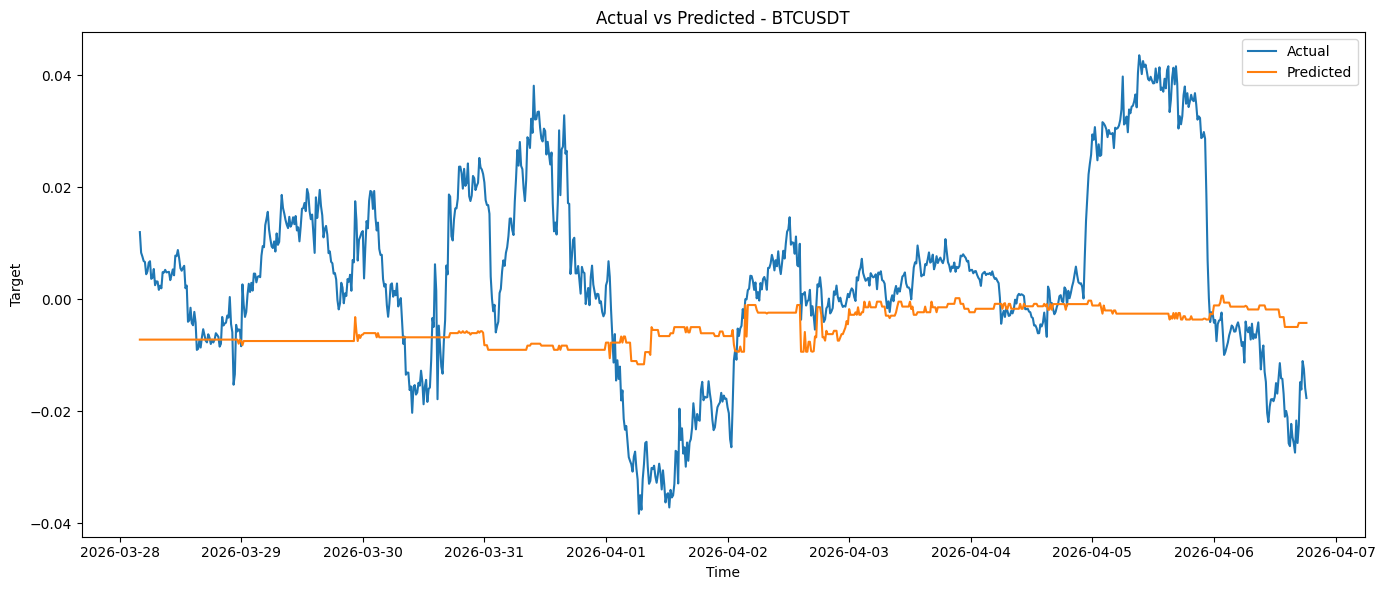

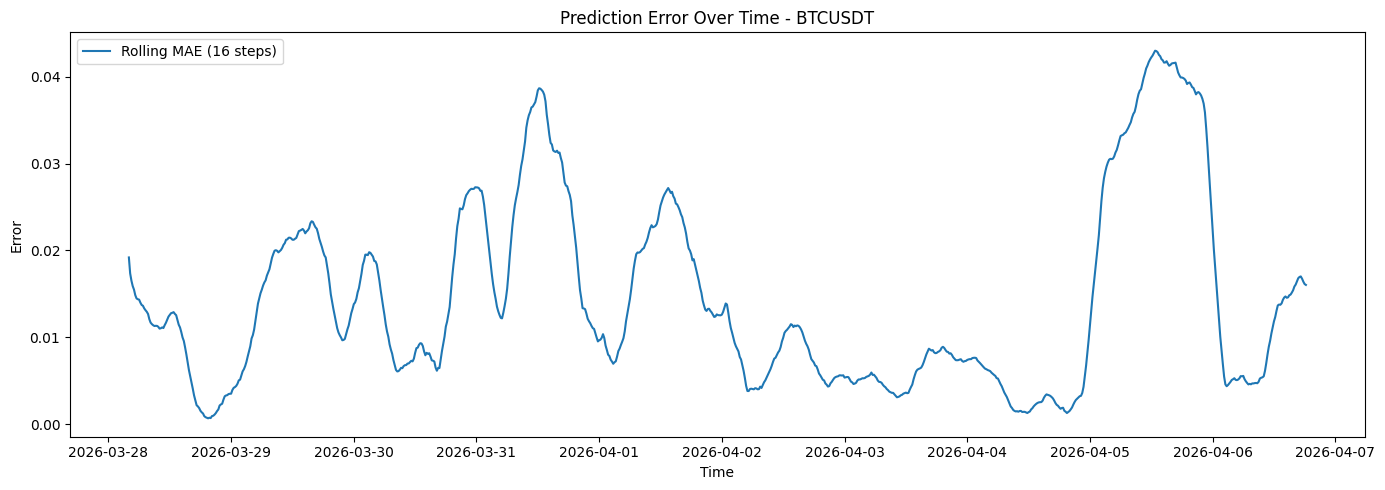

In [30]:
# ============================================================
# FINAL PLOT CELL - ACTUAL vs PREDICTED + ERROR OVER TIME
# Assumes a dataframe like `test_pred_df` exists with:
# open_time, symbol, y_true, y_pred
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# CONFIG
# ----------------------------
PRED_DF_NAME = "test_pred_df"
TIME_COL = "open_time"
SYMBOL_COL = "symbol"
Y_TRUE_COL = "target_ret_96"
Y_PRED_COL = "pred_target_ret_96"

# nếu muốn xem riêng 1 symbol thì điền tên, ví dụ "BTCUSDT"
# nếu để None thì cell sẽ vẽ aggregate mean theo thời gian trên toàn test set
PLOT_SYMBOL = "BTCUSDT"

# rolling window để làm mượt đường error (theo số điểm 15m)
# 16 = 4h, 32 = 8h
ERROR_ROLLING_WINDOW = 16

# ----------------------------
# LOAD DATA
# ----------------------------
pred_df = globals().get(PRED_DF_NAME, None)
if pred_df is None:
    raise ValueError(f"DataFrame '{PRED_DF_NAME}' not found. Update PRED_DF_NAME in this cell.")

plot_df = pred_df.copy()

required_cols = [TIME_COL, SYMBOL_COL, Y_TRUE_COL, Y_PRED_COL]
missing_cols = [c for c in required_cols if c not in plot_df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns in {PRED_DF_NAME}: {missing_cols}")

plot_df[TIME_COL] = pd.to_datetime(plot_df[TIME_COL], utc=True, errors="coerce")
plot_df["error"] = plot_df[Y_PRED_COL] - plot_df[Y_TRUE_COL]
plot_df["abs_error"] = plot_df["error"].abs()
plot_df["sq_error"] = plot_df["error"] ** 2

# ----------------------------
# SELECT VIEW
# ----------------------------
if PLOT_SYMBOL is not None:
    view_df = (
        plot_df.loc[plot_df[SYMBOL_COL] == PLOT_SYMBOL]
        .sort_values(TIME_COL)
        .copy()
    )
    view_df["y_true"] = view_df[Y_TRUE_COL]
    view_df["y_pred"] = view_df[Y_PRED_COL]
    title_suffix = f" - {PLOT_SYMBOL}"
else:
    view_df = (
        plot_df.groupby(TIME_COL, as_index=False)
        .agg(
            y_true=(Y_TRUE_COL, "mean"),
            y_pred=(Y_PRED_COL, "mean"),
            error=("error", "mean"),
            abs_error=("abs_error", "mean"),
            rmse_t=("sq_error", lambda s: np.sqrt(np.mean(s))),
        )
        .sort_values(TIME_COL)
        .copy()
    )
    title_suffix = " - Aggregate Mean Across Test Set"

if view_df.empty:
    raise ValueError("No rows available for plotting after filtering.")

# rolling error for smoother reading
if "abs_error" in view_df.columns:
    view_df["abs_error_roll"] = view_df["abs_error"].rolling(ERROR_ROLLING_WINDOW, min_periods=1).mean()
if "rmse_t" in view_df.columns:
    view_df["rmse_t_roll"] = view_df["rmse_t"].rolling(ERROR_ROLLING_WINDOW, min_periods=1).mean()

# ----------------------------
# METRICS FOR HEADER
# ----------------------------
if PLOT_SYMBOL is not None:
    metric_df = plot_df.loc[plot_df[SYMBOL_COL] == PLOT_SYMBOL].copy()
else:
    metric_df = plot_df.copy()

rmse = np.sqrt(np.mean((metric_df[Y_PRED_COL] - metric_df[Y_TRUE_COL]) ** 2))
mae = np.mean(np.abs(metric_df[Y_PRED_COL] - metric_df[Y_TRUE_COL]))
corr = metric_df[[Y_TRUE_COL, Y_PRED_COL]].corr().iloc[0, 1]
sign_acc = np.mean(np.sign(metric_df[Y_PRED_COL]) == np.sign(metric_df[Y_TRUE_COL]))

print("Plot metrics" + title_suffix)
print(f"RMSE       : {rmse:.6f}")
print(f"MAE        : {mae:.6f}")
print(f"Correlation: {corr:.4f}")
print(f"Sign Acc   : {sign_acc:.4f}")

# ----------------------------
# PLOT 1: ACTUAL vs PREDICTED
# ----------------------------
plt.figure(figsize=(14, 6))
plt.plot(view_df[TIME_COL], view_df["y_true"], label="Actual")
plt.plot(view_df[TIME_COL], view_df["y_pred"], label="Predicted")
plt.title(f"Actual vs Predicted{title_suffix}")
plt.xlabel("Time")
plt.ylabel("Target")
plt.legend()
plt.tight_layout()
plt.show()

# ----------------------------
# PLOT 2: ERROR OVER TIME
# ----------------------------
plt.figure(figsize=(14, 5))
if "abs_error_roll" in view_df.columns:
    plt.plot(view_df[TIME_COL], view_df["abs_error_roll"], label=f"Rolling MAE ({ERROR_ROLLING_WINDOW} steps)")
if "rmse_t_roll" in view_df.columns:
    plt.plot(view_df[TIME_COL], view_df["rmse_t_roll"], label=f"Rolling RMSE ({ERROR_ROLLING_WINDOW} steps)")
plt.title(f"Prediction Error Over Time{title_suffix}")
plt.xlabel("Time")
plt.ylabel("Error")
plt.legend()
plt.tight_layout()
plt.show()